# Semana 7 — MDP y Backward Induction

En esta sesión pasamos de **evaluar una dinámica fija** a **elegir acciones** que modifican la evolución del sistema.

Trabajaremos dos familias de modelos:

- **MDP estacionario de horizonte infinito:** política óptima mediante iteración de valor.
- **MDP de horizonte finito:** política óptima dependiente de la época mediante backward induction.

### Convenciones de programación

El código central utiliza únicamente herramientas trabajadas en las semanas anteriores:

- arreglos de NumPy;
- ciclos `for`;
- condicionales `if`;
- funciones sencillas;
- `np.max`, `np.argmax` y criterios de convergencia.



In [1]:
!pip install jmarkov

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np

## Herramienta nueva: `np.argmax`

En un MDP necesitamos distinguir entre:

- el **mejor valor** entre varias acciones;
- la **posición de la acción** que produce ese valor.

```python
valores_por_accion = np.array([4.2, 6.8])

mejor_valor = np.max(valores_por_accion)
indice_mejor_accion = np.argmax(valores_por_accion)
```

`np.max` devuelve `6.8`, mientras que `np.argmax` devuelve `1`, la posición de la segunda acción.

Durante todo el cuaderno guardaremos las políticas mediante índices enteros y después traduciremos esos índices a nombres.

In [3]:
valores_por_accion_ejemplo = np.array([4.2, 6.8])

mejor_valor_ejemplo = np.max(valores_por_accion_ejemplo)
indice_mejor_accion_ejemplo = np.argmax(valores_por_accion_ejemplo)

print("Valores por acción:", valores_por_accion_ejemplo)
print("Mejor valor:", mejor_valor_ejemplo)
print("Índice de la mejor acción:", indice_mejor_accion_ejemplo)

Valores por acción: [4.2 6.8]
Mejor valor: 6.8
Índice de la mejor acción: 1


---
## Ejercicio 1 — MDP estacionario: Héroes y Villanos

### Contexto

Una ciudad enfrenta ataques periódicos de villanos en dos zonas: el **Centro** y el **Suburbio**. Antes de cada nuevo ataque, el equipo de superhéroes decide en cuál zona posicionarse.

Para evitar ambigüedades, interpretaremos el modelo así:

- El estado $S_t$ indica la zona donde ocurrió el ataque más reciente.
- La acción $A_t$ indica la zona donde los héroes se posicionan antes del siguiente ataque.
- El estado $S_{t+1}$ indica la zona donde ocurre el siguiente ataque.
- Los héroes ganan la batalla cuando la zona elegida coincide con $S_{t+1}$.

El MDP tiene horizonte infinito y factor de descuento $\gamma=0.9$.

### Estados y acciones

$$
\mathcal{S}=\{\text{Centro},\text{Suburbio}\}
$$

$$
\mathcal{A}=\{\text{Ir al Centro},\text{Ir al Suburbio}\}
$$

Para cada acción se define una matriz de transición. Las filas representan el estado actual $S_t$ y las columnas el estado siguiente $S_{t+1}$.

### Acción: Ir al Centro

$$
P^{(\text{Ir al Centro})}
=
\begin{pmatrix}
0.3 & 0.7\\
0.8 & 0.2
\end{pmatrix}
$$

| Estado actual | Próximo ataque en Centro | Próximo ataque en Suburbio |
|---|---:|---:|
| Centro | 0.3 | 0.7 |
| Suburbio | 0.8 | 0.2 |

### Acción: Ir al Suburbio

$$
P^{(\text{Ir al Suburbio})}
=
\begin{pmatrix}
0.5 & 0.5\\
0.6 & 0.4
\end{pmatrix}
$$

| Estado actual | Próximo ataque en Centro | Próximo ataque en Suburbio |
|---|---:|---:|
| Centro | 0.5 | 0.5 |
| Suburbio | 0.6 | 0.4 |

### Recompensa inmediata

La recompensa es la probabilidad de que los héroes se encuentren en la misma zona donde ocurre el próximo ataque. Por tanto:

$$
r(s,\text{Ir al Centro})
=
P(S_{t+1}=\text{Centro}\mid S_t=s,A_t=\text{Ir al Centro})
$$

$$
r(s,\text{Ir al Suburbio})
=
P(S_{t+1}=\text{Suburbio}\mid S_t=s,A_t=\text{Ir al Suburbio})
$$

Con filas correspondientes a los estados **Centro** y **Suburbio**, y columnas correspondientes a las acciones **Ir al Centro** e **Ir al Suburbio**, la matriz de recompensas es:

$$
R=
\begin{pmatrix}
0.3 & 0.5\\
0.8 & 0.4
\end{pmatrix}
$$

Por ejemplo, si el ataque anterior ocurrió en el Suburbio y los héroes eligen **Ir al Centro**, la probabilidad de ganar la siguiente batalla es $0.8$.


### 1.1 Una actualización de Bellman

Partimos de:

\[
V^{(0)}=
\begin{bmatrix}
0&0
\end{bmatrix}.
\]

Para cada estado calculamos un valor por acción:

$$
Q(s,a)
=
r(s,a)
+
\gamma
\sum_{s'} P(s'|s,a) V^{(0)}(s')
$$

Después elegimos:

$$
V^{(1)}(s) = \max_a Q(s,a).
$$

La siguiente celda desarrolla una actualización completa antes de construir el ciclo general.

In [4]:
estados_heroes = np.array(["Centro", "Suburbio"])
acciones_heroes = np.array([
    "Ir al Centro",
    "Ir al Suburbio"
])

P_ir_centro = np.array([
    [0.3, 0.7],
    [0.8, 0.2]
])

P_ir_suburbio = np.array([
    [0.5, 0.5],
    [0.6, 0.4]
])

matrices_heroes_por_accion = [
    P_ir_centro,
    P_ir_suburbio
]

retornos_heroes = np.array([
    [0.3, 0.5],
    [0.8, 0.4]
])

gamma_heroes = 0.9
numero_estados_heroes = len(estados_heroes)
numero_acciones_heroes = len(acciones_heroes)

valor_inicial_heroes = np.zeros(numero_estados_heroes)
valor_primera_iteracion = np.zeros(numero_estados_heroes)

for estado_actual in range(numero_estados_heroes):

    valores_por_accion = np.zeros(numero_acciones_heroes)

    for accion_actual in range(numero_acciones_heroes):

        continuacion = 0.0

        for estado_siguiente in range(numero_estados_heroes):

            probabilidad = matrices_heroes_por_accion[
                accion_actual
            ][estado_actual, estado_siguiente]

            continuacion = (
                continuacion
                + probabilidad
                * valor_inicial_heroes[estado_siguiente]
            )

        valores_por_accion[accion_actual] = (
            retornos_heroes[estado_actual, accion_actual]
            + gamma_heroes * continuacion
        )

    valor_primera_iteracion[estado_actual] = np.max(
        valores_por_accion
    )

    print(
        "Estado:",
        estados_heroes[estado_actual]
    )
    print(
        "Valores por acción:",
        np.round(valores_por_accion, 4)
    )
    print(
        "Mejor valor:",
        round(valor_primera_iteracion[estado_actual], 4)
    )
    print()

print(
    "V después de la primera iteración:",
    valor_primera_iteracion
)

Estado: Centro
Valores por acción: [0.3 0.5]
Mejor valor: 0.5

Estado: Suburbio
Valores por acción: [0.8 0.4]
Mejor valor: 0.8

V después de la primera iteración: [0.5 0.8]


### 1.2 Iteración de valor hasta converger

Aplicamos repetidamente:

$$
V^{(k+1)}(s)
=
\max_a
\left[
r(s,a)
+
\gamma
\sum_{s'} P(s'|s,a) V^{(k)}(s')
\right].
$$

La dificultad nueva está en evaluar **todas las acciones** antes de guardar el mejor valor.

In [5]:
tolerancia_heroes = 0.000001
maximo_iteraciones_heroes = 10000

valor_heroes = np.zeros(numero_estados_heroes)
historial_cambios_heroes = []

for iteracion in range(1, maximo_iteraciones_heroes + 1):

    valor_nuevo = np.zeros(numero_estados_heroes)

    for estado_actual in range(numero_estados_heroes):

        valores_por_accion = np.zeros(
            numero_acciones_heroes
        )

        for accion_actual in range(
            numero_acciones_heroes
        ):

            continuacion = 0.0

            for estado_siguiente in range(
                numero_estados_heroes
            ):

                probabilidad = (
                    matrices_heroes_por_accion[
                        accion_actual
                    ][
                        estado_actual,
                        estado_siguiente
                    ]
                )

                continuacion = (
                    continuacion
                    + probabilidad
                    * valor_heroes[estado_siguiente]
                )

            valores_por_accion[accion_actual] = (
                retornos_heroes[
                    estado_actual,
                    accion_actual
                ]
                + gamma_heroes * continuacion
            )

        valor_nuevo[estado_actual] = np.max(
            valores_por_accion
        )

    cambio_maximo = np.max(
        np.abs(valor_nuevo - valor_heroes)
    )

    historial_cambios_heroes.append(cambio_maximo)

    valor_heroes = valor_nuevo.copy()

    if cambio_maximo < tolerancia_heroes:
        break

print("Iteraciones realizadas:", iteracion)
print("Valor óptimo aproximado:")

for estado_actual in range(numero_estados_heroes):
    print(
        estados_heroes[estado_actual],
        "->",
        round(valor_heroes[estado_actual], 4)
    )

Iteraciones realizadas: 128
Valor óptimo aproximado:
Centro -> 6.063
Suburbio -> 6.2992


### Visualización proporcionada

La siguiente gráfica **no hace parte de los contenidos de programación evaluados**. No es necesario comprender todos los comandos de Matplotlib en la primera lectura.

Concéntrese en interpretar cómo el cambio máximo disminuye hasta quedar por debajo de la tolerancia.

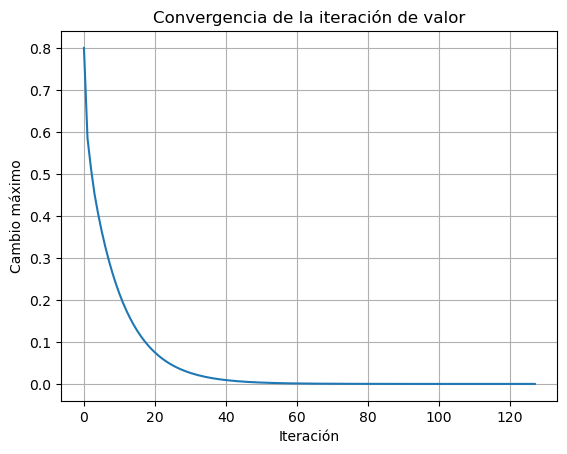

In [6]:
import matplotlib.pyplot as plt

plt.plot(historial_cambios_heroes)
plt.xlabel("Iteración")
plt.ylabel("Cambio máximo")
plt.title("Convergencia de la iteración de valor")
plt.grid()
plt.show()

### 1.3 Política óptima

Una vez calculado $V^*$, volvemos a evaluar las acciones y guardamos el índice de la acción que maximiza el valor.

In [8]:
politica_indices_heroes = np.zeros(
    numero_estados_heroes,
    dtype=int
)

for estado_actual in range(numero_estados_heroes):

    valores_por_accion = np.zeros(
        numero_acciones_heroes
    )

    for accion_actual in range(
        numero_acciones_heroes
    ):

        continuacion = 0.0

        for estado_siguiente in range(
            numero_estados_heroes
        ):

            probabilidad = (
                matrices_heroes_por_accion[
                    accion_actual
                ][
                    estado_actual,
                    estado_siguiente
                ]
            )

            continuacion = (
                continuacion
                + probabilidad
                * valor_heroes[estado_siguiente]
            )

        valores_por_accion[accion_actual] = (
            retornos_heroes[
                estado_actual,
                accion_actual
            ]
            + gamma_heroes * continuacion
        )

    politica_indices_heroes[estado_actual] = (
        np.argmax(valores_por_accion)
    )

print("Política óptima:")

for estado_actual in range(numero_estados_heroes):

    indice_accion = politica_indices_heroes[
        estado_actual
    ]

    print(
        "Si el estado es",
        estados_heroes[estado_actual],
        "->",
        acciones_heroes[indice_accion]
    )

Política óptima:
Si el estado es Centro -> Ir al Suburbio
Si el estado es Suburbio -> Ir al Centro


### 1.4 Cadena inducida por la política

La política elige una acción en cada estado. Por tanto, la fila correspondiente de la matriz inducida se toma de la matriz de transición de esa acción.

In [9]:
P_politica_heroes = np.zeros(
    (
        numero_estados_heroes,
        numero_estados_heroes
    )
)

for estado_actual in range(numero_estados_heroes):

    accion_elegida = politica_indices_heroes[
        estado_actual
    ]

    P_politica_heroes[
        estado_actual, :
    ] = matrices_heroes_por_accion[
        accion_elegida
    ][estado_actual, :]

print("Matriz inducida por la política:")
print(np.round(P_politica_heroes, 4))

distribucion_heroes = np.array([0.5, 0.5])
tolerancia_estacionaria = 0.000001

for iteracion_estacionaria in range(1, 1001):

    distribucion_nueva = (
        distribucion_heroes
        @ P_politica_heroes
    )

    cambio_distribucion = np.max(
        np.abs(
            distribucion_nueva
            - distribucion_heroes
        )
    )

    distribucion_heroes = (
        distribucion_nueva.copy()
    )

    if (
        cambio_distribucion
        < tolerancia_estacionaria
    ):
        break

print()
print("Distribución estacionaria:")

for estado_actual in range(numero_estados_heroes):
    print(
        estados_heroes[estado_actual],
        "->",
        round(
            distribucion_heroes[estado_actual],
            4
        )
    )

valor_descontado_ponderado = (
    distribucion_heroes @ valor_heroes
)

print()
print(
    "Valor descontado ponderado:",
    round(valor_descontado_ponderado, 4)
)

Matriz inducida por la política:
[[0.5 0.5]
 [0.8 0.2]]

Distribución estacionaria:
Centro -> 0.6154
Suburbio -> 0.3846

Valor descontado ponderado: 6.1538


> **Interpretación:** el valor anterior es el valor descontado esperado cuando el estado inicial se distribuye según la distribución estacionaria inducida. No es todavía una recompensa promedio por período.

### Verificación proporcionada con `jmarkov`

Los diccionarios de esta celda responden a la interfaz de `jmarkov`. No se espera que el estudiante memorice esta sintaxis. El objetivo es comparar los resultados de la librería con el algoritmo implementado manualmente.

In [10]:
from jmarkov.mdp.dtmdp import dtmdp
from jmarkov.dtmc import dtmc

matrices_heroes_jmarkov = {}
matrices_heroes_jmarkov[
    "Ir al Centro"
] = P_ir_centro
matrices_heroes_jmarkov[
    "Ir al Suburbio"
] = P_ir_suburbio

mdp_heroes = dtmdp(
    estados_heroes,
    acciones_heroes,
    matrices_heroes_jmarkov,
    retornos_heroes,
    gamma_heroes
)

valor_heroes_jmarkov, politica_heroes_jmarkov = (
    mdp_heroes.solve(
        0,
        minimize=False,
        method="policy_iteration"
    )
)

print(
    "Valor calculado manualmente:",
    np.round(valor_heroes, 4)
)

print(
    "Valor calculado con jmarkov:",
    np.round(
        np.array(
            valor_heroes_jmarkov,
            dtype=float
        ),
        4
    )
)

print(
    "Política calculada con jmarkov:",
    politica_heroes_jmarkov
)

P_heroes_jmarkov = (
    mdp_heroes.policy_transition_matrix(
        politica_heroes_jmarkov
    )
)

cadena_heroes_jmarkov = dtmc(
    P_heroes_jmarkov,
    states=estados_heroes
)

distribucion_jmarkov = (
    cadena_heroes_jmarkov.steady_state()
)

print(
    "Distribución manual:",
    np.round(distribucion_heroes, 4)
)

print(
    "Distribución jmarkov:",
    np.round(distribucion_jmarkov, 4)
)

Valor calculado manualmente: [6.063  6.2992]
Valor calculado con jmarkov: [6.063  6.2992]
Política calculada con jmarkov: {'Centro': 'Ir al Suburbio', 'Suburbio': 'Ir al Centro'}
Distribución manual: [0.6154 0.3846]
Distribución jmarkov: [0.6154 0.3846]


---
## Ejercicio 2 — MDP de horizonte finito: reemplazo de máquinas

Una empresa opera una máquina durante tres semanas. Al comienzo de cada semana observa su estado y decide entre:

- **Reemplazar**;
- **No reemplazar**.

Los estados son:

$$
\mathcal S=
\{\text{Excelente},\text{Bueno},\text{Promedio},\text{Malo}\}.
$$

Los retornos inmediatos son:

$$
\begin{array}{c|cc}
&\text{Reemplazar}&\text{No reemplazar}\\
\hline
\text{Excelente}&-1000&100\\
\text{Bueno}&-100&80\\
\text{Promedio}&-100&50\\
\text{Malo}&-100&10
\end{array}.
$$

La acción Reemplazar no es factible en Excelente. Se conserva una fila de transición válida, pero su retorno de \(-1000\) evita que sea elegida.

Usaremos siempre la convención:

```python
V[epoca, estado]
politica[epoca, estado]
```

### 2.1 Datos del modelo

Los retornos y las transiciones son iguales en las tres semanas. Por eso no necesitamos un arreglo tridimensional para el algoritmo manual.

In [11]:
epocas_maquina = np.array([1, 2, 3])

estados_maquina = np.array([
    "Excelente",
    "Bueno",
    "Promedio",
    "Malo"
])

acciones_maquina = np.array([
    "Reemplazar",
    "No reemplazar"
])

gamma_maquina = 0.9

retornos_maquina = np.array([
    [-1000, 100],
    [-100,   80],
    [-100,   50],
    [-100,   10]
])

P_no_reemplazar = np.array([
    [0.7, 0.3, 0.0, 0.0],
    [0.0, 0.7, 0.3, 0.0],
    [0.0, 0.0, 0.7, 0.3],
    [0.0, 0.0, 0.0, 1.0]
])

P_reemplazar = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.7, 0.3, 0.0, 0.0],
    [0.7, 0.3, 0.0, 0.0],
    [0.7, 0.3, 0.0, 0.0]
])

matrices_maquina_por_accion = [
    P_reemplazar,
    P_no_reemplazar
]

numero_epocas_maquina = len(epocas_maquina)
numero_estados_maquina = len(estados_maquina)
numero_acciones_maquina = len(
    acciones_maquina
)

for indice_accion in range(
    numero_acciones_maquina
):

    print(
        "Acción:",
        acciones_maquina[indice_accion]
    )

    for estado_actual in range(
        numero_estados_maquina
    ):

        suma_fila = (
            matrices_maquina_por_accion[
                indice_accion
            ][estado_actual, :].sum()
        )

        print(
            estados_maquina[estado_actual],
            "-> suma:",
            round(suma_fila, 4)
        )

    print()

Acción: Reemplazar
Excelente -> suma: 1.0
Bueno -> suma: 1.0
Promedio -> suma: 1.0
Malo -> suma: 1.0

Acción: No reemplazar
Excelente -> suma: 1.0
Bueno -> suma: 1.0
Promedio -> suma: 1.0
Malo -> suma: 1.0



### 2.2 Backward induction

En la última época no existe continuación futura:

$$
V_T(s)=\max_a r(s,a).
$$

Para las épocas anteriores:

$$
V_t(s)
=
\max_a
\left[
r(s,a)
+
\gamma
\sum_{s'} P(s'|s,a) V_{t+1}(s')
\right].
$$

In [12]:
valor_maquina = np.zeros(
    (
        numero_epocas_maquina,
        numero_estados_maquina
    )
)

politica_maquina = np.zeros(
    (
        numero_epocas_maquina,
        numero_estados_maquina
    ),
    dtype=int
)

ultima_epoca = numero_epocas_maquina - 1

for estado_actual in range(
    numero_estados_maquina
):

    valores_por_accion = retornos_maquina[
        estado_actual, :
    ]

    valor_maquina[
        ultima_epoca,
        estado_actual
    ] = np.max(valores_por_accion)

    politica_maquina[
        ultima_epoca,
        estado_actual
    ] = np.argmax(valores_por_accion)

for epoca in range(
    numero_epocas_maquina - 2,
    -1,
    -1
):

    for estado_actual in range(
        numero_estados_maquina
    ):

        valores_por_accion = np.zeros(
            numero_acciones_maquina
        )

        for accion_actual in range(
            numero_acciones_maquina
        ):

            continuacion = 0.0

            for estado_siguiente in range(
                numero_estados_maquina
            ):

                probabilidad = (
                    matrices_maquina_por_accion[
                        accion_actual
                    ][
                        estado_actual,
                        estado_siguiente
                    ]
                )

                continuacion = (
                    continuacion
                    + probabilidad
                    * valor_maquina[
                        epoca + 1,
                        estado_siguiente
                    ]
                )

            valores_por_accion[
                accion_actual
            ] = (
                retornos_maquina[
                    estado_actual,
                    accion_actual
                ]
                + gamma_maquina * continuacion
            )

        valor_maquina[
            epoca,
            estado_actual
        ] = np.max(valores_por_accion)

        politica_maquina[
            epoca,
            estado_actual
        ] = np.argmax(valores_por_accion)

In [13]:
print("Funciones de valor:")

for estado_actual in range(
    numero_estados_maquina
):

    print()
    print(
        "Estado:",
        estados_maquina[estado_actual]
    )

    for epoca in range(
        numero_epocas_maquina
    ):

        print(
            "Semana",
            epocas_maquina[epoca],
            "->",
            round(
                valor_maquina[
                    epoca,
                    estado_actual
                ],
                2
            )
        )

print()
print("Política óptima:")

for estado_actual in range(
    numero_estados_maquina
):

    print()
    print(
        "Estado:",
        estados_maquina[estado_actual]
    )

    for epoca in range(
        numero_epocas_maquina
    ):

        accion_elegida = politica_maquina[
            epoca,
            estado_actual
        ]

        print(
            "Semana",
            epocas_maquina[epoca],
            "->",
            acciones_maquina[accion_elegida]
        )

indice_malo = 3

print()
print(
    "Ganancia esperada desde Malo en la semana 1:",
    round(valor_maquina[0, indice_malo], 2)
)

Funciones de valor:

Estado: Excelente
Semana 1 -> 255.15
Semana 2 -> 184.6
Semana 3 -> 100.0

Estado: Bueno
Semana 1 -> 193.39
Semana 2 -> 143.9
Semana 3 -> 80.0

Estado: Promedio
Semana 1 -> 108.18
Semana 2 -> 84.2
Semana 3 -> 50.0

Estado: Malo
Semana 1 -> 55.15
Semana 2 -> 19.0
Semana 3 -> 10.0

Política óptima:

Estado: Excelente
Semana 1 -> No reemplazar
Semana 2 -> No reemplazar
Semana 3 -> No reemplazar

Estado: Bueno
Semana 1 -> No reemplazar
Semana 2 -> No reemplazar
Semana 3 -> No reemplazar

Estado: Promedio
Semana 1 -> No reemplazar
Semana 2 -> No reemplazar
Semana 3 -> No reemplazar

Estado: Malo
Semana 1 -> Reemplazar
Semana 2 -> No reemplazar
Semana 3 -> No reemplazar

Ganancia esperada desde Malo en la semana 1: 55.15


### Verificación proporcionada con `jmarkov`

Para la interfaz de `dtsdp`, replicamos los mismos retornos y matrices en cada época. Este código auxiliar no es parte central del algoritmo.

In [14]:
from jmarkov.sdp.dtsdp import dtsdp

retornos_maquina_jmarkov = np.zeros(
    (
        numero_epocas_maquina,
        numero_estados_maquina,
        numero_acciones_maquina
    )
)

for epoca in range(numero_epocas_maquina):

    retornos_maquina_jmarkov[
        epoca, :, :
    ] = retornos_maquina

probabilidades_maquina_jmarkov = {}

for epoca in range(
    numero_epocas_maquina
):

    numero_epoca = epocas_maquina[epoca]

    probabilidades_maquina_jmarkov[
        numero_epoca
    ] = {}

    probabilidades_maquina_jmarkov[
        numero_epoca
    ]["Reemplazar"] = P_reemplazar

    probabilidades_maquina_jmarkov[
        numero_epoca
    ]["No reemplazar"] = P_no_reemplazar

sdp_maquina = dtsdp(
    epocas_maquina,
    estados_maquina,
    acciones_maquina,
    probabilidades_maquina_jmarkov,
    retornos_maquina_jmarkov,
    gamma_maquina
)

valor_maquina_jmarkov, politica_maquina_jmarkov = (
    sdp_maquina.solve(minimize=False)
)

print(
    "Valor manual, organizado como estados x épocas:"
)
print(np.round(valor_maquina.T, 3))

print(
    "Valor jmarkov:"
)
print(
    np.round(
        np.array(
            valor_maquina_jmarkov,
            dtype=float
        ),
        3
    )
)

Valor manual, organizado como estados x épocas:
[[255.151 184.6   100.   ]
 [193.391 143.9    80.   ]
 [108.176  84.2    50.   ]
 [ 55.151  19.     10.   ]]
Valor jmarkov:
[[255.151 184.6   100.   ]
 [193.391 143.9    80.   ]
 [108.176  84.2    50.   ]
 [ 55.151  19.     10.   ]]


---
## Función reutilizable para backward induction

El procedimiento anterior ya se desarrolló completamente. Ahora lo encapsulamos en una función para reutilizarlo.

La función supone que:

- las matrices de transición dependen de la acción;
- los retornos no cambian entre épocas;
- `valor[epoca, estado]`;
- `politica[epoca, estado]`.

In [15]:
def backward_induction(
    matrices_por_accion,
    retornos,
    numero_epocas,
    gamma
):

    numero_estados = retornos.shape[0]
    numero_acciones = retornos.shape[1]

    valor = np.zeros(
        (numero_epocas, numero_estados)
    )

    politica = np.zeros(
        (numero_epocas, numero_estados),
        dtype=int
    )

    ultima_epoca = numero_epocas - 1

    for estado_actual in range(
        numero_estados
    ):

        valores_por_accion = retornos[
            estado_actual, :
        ]

        valor[
            ultima_epoca,
            estado_actual
        ] = np.max(valores_por_accion)

        politica[
            ultima_epoca,
            estado_actual
        ] = np.argmax(valores_por_accion)

    for epoca in range(
        numero_epocas - 2,
        -1,
        -1
    ):

        for estado_actual in range(
            numero_estados
        ):

            valores_por_accion = np.zeros(
                numero_acciones
            )

            for accion_actual in range(
                numero_acciones
            ):

                continuacion = 0.0

                for estado_siguiente in range(
                    numero_estados
                ):

                    probabilidad = (
                        matrices_por_accion[
                            accion_actual
                        ][
                            estado_actual,
                            estado_siguiente
                        ]
                    )

                    continuacion = (
                        continuacion
                        + probabilidad
                        * valor[
                            epoca + 1,
                            estado_siguiente
                        ]
                    )

                valores_por_accion[
                    accion_actual
                ] = (
                    retornos[
                        estado_actual,
                        accion_actual
                    ]
                    + gamma * continuacion
                )

            valor[
                epoca,
                estado_actual
            ] = np.max(valores_por_accion)

            politica[
                epoca,
                estado_actual
            ] = np.argmax(valores_por_accion)

    return valor, politica

---
## Ejercicio 3 — Newsvendor multiperíodo: política \((s_t,S_t)\)

EcoFlor S.A.S. gestiona ramos durante tres semanas.

- Inventario máximo: 5.
- Estados: inventario inicial $0,\ldots,5$.
- Acciones: pedir $0,\ldots,5$.
- Demanda: $D\in\{0,1,2,3,4\}$.
- Precio: 50.
- Costo de pedido: 25.
- Costo de almacenamiento: 8.
- Costo de escasez: 15.

Las acciones con $(i+a>5)$ reciben una penalización grande.

### 3.1 Construcción de retornos

Los retornos son iguales en todas las épocas. Por eso construimos una matriz bidimensional:

```python
retornos[estado, accion]
```

In [16]:
capacidad_inventario = 5

precio_venta = 50
costo_pedido = 25
costo_almacenamiento = 8
costo_escasez = 15

penalizacion_infactible = -10000

valores_demanda = np.array([
    0, 1, 2, 3, 4
])

probabilidades_demanda = np.array([
    0.10,
    0.30,
    0.30,
    0.20,
    0.10
])

epocas_inventario = np.array([1, 2, 3])

estados_inventario = np.array([
    "0", "1", "2", "3", "4", "5"
])

acciones_inventario = np.array([
    "Pedir 0",
    "Pedir 1",
    "Pedir 2",
    "Pedir 3",
    "Pedir 4",
    "Pedir 5"
])

numero_epocas_inventario = len(
    epocas_inventario
)

numero_estados_inventario = len(
    estados_inventario
)

numero_acciones_inventario = len(
    acciones_inventario
)

In [17]:
def construir_retornos_inventario(
    costo_escasez_modelo
):

    retornos = np.zeros(
        (
            numero_estados_inventario,
            numero_acciones_inventario
        )
    )

    for inventario_actual in range(
        numero_estados_inventario
    ):

        for cantidad_pedida in range(
            numero_acciones_inventario
        ):

            inventario_disponible = (
                inventario_actual
                + cantidad_pedida
            )

            if (
                inventario_disponible
                > capacidad_inventario
            ):

                retornos[
                    inventario_actual,
                    cantidad_pedida
                ] = penalizacion_infactible

            else:

                retorno_esperado = (
                    -costo_pedido
                    * cantidad_pedida
                )

                for indice_demanda in range(
                    len(valores_demanda)
                ):

                    demanda = valores_demanda[
                        indice_demanda
                    ]

                    probabilidad_demanda = (
                        probabilidades_demanda[
                            indice_demanda
                        ]
                    )

                    ventas = min(
                        inventario_disponible,
                        demanda
                    )

                    inventario_sobrante = max(
                        0,
                        inventario_disponible
                        - demanda
                    )

                    demanda_insatisfecha = max(
                        0,
                        demanda
                        - inventario_disponible
                    )

                    retorno_escenario = (
                        precio_venta * ventas
                        - costo_almacenamiento
                        * inventario_sobrante
                        - costo_escasez_modelo
                        * demanda_insatisfecha
                    )

                    retorno_esperado = (
                        retorno_esperado
                        + probabilidad_demanda
                        * retorno_escenario
                    )

                retornos[
                    inventario_actual,
                    cantidad_pedida
                ] = retorno_esperado

    return retornos

In [18]:
retornos_inventario = (
    construir_retornos_inventario(
        costo_escasez
    )
)

print(
    "Retornos esperados para las tres primeras acciones:"
)
print(
    np.round(
        retornos_inventario[:, 0:3],
        2
    )
)

Retornos esperados para las tres primeras acciones:
[[-2.85e+01  4.20e+00  1.50e+01]
 [ 2.92e+01  4.00e+01  2.89e+01]
 [ 6.50e+01  5.39e+01  2.82e+01]
 [ 7.89e+01  5.32e+01  2.02e+01]
 [ 7.82e+01  4.52e+01 -1.00e+04]
 [ 7.02e+01 -1.00e+04 -1.00e+04]]


### 3.2 Construcción de matrices de transición

Cada acción produce una matriz. Las acciones infactibles reciben una transición ficticia de autorretorno; la penalización impide que sean elegidas.

In [20]:
def construir_matriz_transicion_inventario(
    cantidad_pedida
):

    matriz = np.zeros(
        (
            numero_estados_inventario,
            numero_estados_inventario
        )
    )

    for inventario_actual in range(
        numero_estados_inventario
    ):

        inventario_disponible = (
            inventario_actual
            + cantidad_pedida
        )

        if (
            inventario_disponible
            > capacidad_inventario
        ):

            matriz[
                inventario_actual,
                inventario_actual
            ] = 1.0

        else:

            for indice_demanda in range(
                len(valores_demanda)
            ):

                demanda = valores_demanda[
                    indice_demanda
                ]

                probabilidad_demanda = (
                    probabilidades_demanda[
                        indice_demanda
                    ]
                )

                inventario_siguiente = max(
                    0,
                    inventario_disponible
                    - demanda
                )

                matriz[
                    inventario_actual,
                    inventario_siguiente
                ] = (
                    matriz[
                        inventario_actual,
                        inventario_siguiente
                    ]
                    + probabilidad_demanda
                )

    return matriz

In [21]:
matrices_inventario_por_accion = []

for cantidad_pedida in range(
    numero_acciones_inventario
):

    matriz_accion = (
        construir_matriz_transicion_inventario(
            cantidad_pedida
        )
    )

    matrices_inventario_por_accion.append(
        matriz_accion
    )

for cantidad_pedida in range(
    numero_acciones_inventario
):

    print(
        "Acción:",
        acciones_inventario[
            cantidad_pedida
        ]
    )

    for inventario_actual in range(
        numero_estados_inventario
    ):

        suma_fila = (
            matrices_inventario_por_accion[
                cantidad_pedida
            ][inventario_actual, :].sum()
        )

        print(
            "Estado",
            inventario_actual,
            "-> suma:",
            round(suma_fila, 4)
        )

    print()

Acción: Pedir 0
Estado 0 -> suma: 1.0
Estado 1 -> suma: 1.0
Estado 2 -> suma: 1.0
Estado 3 -> suma: 1.0
Estado 4 -> suma: 1.0
Estado 5 -> suma: 1.0

Acción: Pedir 1
Estado 0 -> suma: 1.0
Estado 1 -> suma: 1.0
Estado 2 -> suma: 1.0
Estado 3 -> suma: 1.0
Estado 4 -> suma: 1.0
Estado 5 -> suma: 1.0

Acción: Pedir 2
Estado 0 -> suma: 1.0
Estado 1 -> suma: 1.0
Estado 2 -> suma: 1.0
Estado 3 -> suma: 1.0
Estado 4 -> suma: 1.0
Estado 5 -> suma: 1.0

Acción: Pedir 3
Estado 0 -> suma: 1.0
Estado 1 -> suma: 1.0
Estado 2 -> suma: 1.0
Estado 3 -> suma: 1.0
Estado 4 -> suma: 1.0
Estado 5 -> suma: 1.0

Acción: Pedir 4
Estado 0 -> suma: 1.0
Estado 1 -> suma: 1.0
Estado 2 -> suma: 1.0
Estado 3 -> suma: 1.0
Estado 4 -> suma: 1.0
Estado 5 -> suma: 1.0

Acción: Pedir 5
Estado 0 -> suma: 1.0
Estado 1 -> suma: 1.0
Estado 2 -> suma: 1.0
Estado 3 -> suma: 1.0
Estado 4 -> suma: 1.0
Estado 5 -> suma: 1.0



### 3.3 Backward induction y política

Aplicamos la función desarrollada después del ejercicio de reemplazo.

In [22]:
valor_inventario, politica_inventario = (
    backward_induction(
        matrices_inventario_por_accion,
        retornos_inventario,
        numero_epocas_inventario,
        gamma=1.0
    )
)

print("Política óptima: unidades a pedir")

for inventario_actual in range(
    numero_estados_inventario
):

    print()
    print(
        "Inventario inicial:",
        inventario_actual
    )

    for epoca in range(
        numero_epocas_inventario
    ):

        cantidad_pedida = (
            politica_inventario[
                epoca,
                inventario_actual
            ]
        )

        print(
            "Semana",
            epocas_inventario[epoca],
            "-> pedir",
            cantidad_pedida
        )

print()
print(
    "Ganancia esperada desde inventario 0:",
    round(valor_inventario[0, 0], 2)
)

Política óptima: unidades a pedir

Inventario inicial: 0
Semana 1 -> pedir 3
Semana 2 -> pedir 3
Semana 3 -> pedir 2

Inventario inicial: 1
Semana 1 -> pedir 2
Semana 2 -> pedir 2
Semana 3 -> pedir 1

Inventario inicial: 2
Semana 1 -> pedir 1
Semana 2 -> pedir 1
Semana 3 -> pedir 0

Inventario inicial: 3
Semana 1 -> pedir 0
Semana 2 -> pedir 0
Semana 3 -> pedir 0

Inventario inicial: 4
Semana 1 -> pedir 0
Semana 2 -> pedir 0
Semana 3 -> pedir 0

Inventario inicial: 5
Semana 1 -> pedir 0
Semana 2 -> pedir 0
Semana 3 -> pedir 0

Ganancia esperada desde inventario 0: 81.69


### 3.4 ¿Tiene estructura $(s_t,S_t)$?

Para cada época comprobamos:

1. hasta qué inventario se ordena;
2. a qué nivel queda el inventario después de ordenar;
3. si todos los estados que ordenan llegan al mismo nivel objetivo.

In [23]:
print("Revisión de la estructura (s_t, S_t):")

for epoca in range(
    numero_epocas_inventario
):

    punto_reorden = -1
    nivel_objetivo = -1
    estructura_sS = True

    for inventario_actual in range(
        numero_estados_inventario
    ):

        cantidad_pedida = (
            politica_inventario[
                epoca,
                inventario_actual
            ]
        )

        if cantidad_pedida > 0:

            punto_reorden = inventario_actual

            inventario_despues_pedido = (
                inventario_actual
                + cantidad_pedida
            )

            if nivel_objetivo == -1:

                nivel_objetivo = (
                    inventario_despues_pedido
                )

            elif (
                inventario_despues_pedido
                != nivel_objetivo
            ):

                estructura_sS = False

    print()
    print(
        "Semana:",
        epocas_inventario[epoca]
    )
    print(
        "s_t:",
        punto_reorden
    )
    print(
        "S_t:",
        nivel_objetivo
    )
    print(
        "¿Estructura consistente?:",
        estructura_sS
    )

Revisión de la estructura (s_t, S_t):

Semana: 1
s_t: 2
S_t: 3
¿Estructura consistente?: True

Semana: 2
s_t: 2
S_t: 3
¿Estructura consistente?: True

Semana: 3
s_t: 1
S_t: 2
¿Estructura consistente?: True


### 3.5 Sensibilidad al costo de escasez

Aumentamos el costo de escasez de 15 a 30. La política puede permanecer igual aunque cambien los valores esperados; una modificación del parámetro no tiene que cambiar necesariamente el `argmax`.

In [24]:
costo_escasez_alternativo = 30

retornos_inventario_alternativos = (
    construir_retornos_inventario(
        costo_escasez_alternativo
    )
)

valor_inventario_alternativo, politica_inventario_alternativa = (
    backward_induction(
        matrices_inventario_por_accion,
        retornos_inventario_alternativos,
        numero_epocas_inventario,
        gamma=1.0
    )
)

print("Comparación de políticas:")

for inventario_actual in range(
    numero_estados_inventario
):

    print()
    print(
        "Inventario:",
        inventario_actual
    )

    for epoca in range(
        numero_epocas_inventario
    ):

        accion_original = (
            politica_inventario[
                epoca,
                inventario_actual
            ]
        )

        accion_alternativa = (
            politica_inventario_alternativa[
                epoca,
                inventario_actual
            ]
        )

        print(
            "Semana",
            epocas_inventario[epoca],
            "-> original:",
            accion_original,
            "| costo alto:",
            accion_alternativa
        )

print()
print(
    "Cambio del valor desde inventario 0:",
    round(
        valor_inventario_alternativo[0, 0]
        - valor_inventario[0, 0],
        2
    )
)

Comparación de políticas:

Inventario: 0
Semana 1 -> original: 3 | costo alto: 3
Semana 2 -> original: 3 | costo alto: 3
Semana 3 -> original: 2 | costo alto: 2

Inventario: 1
Semana 1 -> original: 2 | costo alto: 2
Semana 2 -> original: 2 | costo alto: 2
Semana 3 -> original: 1 | costo alto: 1

Inventario: 2
Semana 1 -> original: 1 | costo alto: 1
Semana 2 -> original: 1 | costo alto: 1
Semana 3 -> original: 0 | costo alto: 0

Inventario: 3
Semana 1 -> original: 0 | costo alto: 0
Semana 2 -> original: 0 | costo alto: 0
Semana 3 -> original: 0 | costo alto: 0

Inventario: 4
Semana 1 -> original: 0 | costo alto: 0
Semana 2 -> original: 0 | costo alto: 0
Semana 3 -> original: 0 | costo alto: 0

Inventario: 5
Semana 1 -> original: 0 | costo alto: 0
Semana 2 -> original: 0 | costo alto: 0
Semana 3 -> original: 0 | costo alto: 0

Cambio del valor desde inventario 0: -8.55


### Verificación proporcionada con `jmarkov`

Esta celda transforma las listas de matrices y los retornos bidimensionales al formato exigido por `dtsdp`. No es necesario memorizar su sintaxis.

In [25]:
probabilidades_inventario_jmarkov = {}

for epoca in range(
    numero_epocas_inventario
):

    numero_epoca = epocas_inventario[epoca]

    probabilidades_inventario_jmarkov[
        numero_epoca
    ] = {}

    for cantidad_pedida in range(
        numero_acciones_inventario
    ):

        nombre_accion = (
            acciones_inventario[
                cantidad_pedida
            ]
        )

        probabilidades_inventario_jmarkov[
            numero_epoca
        ][nombre_accion] = (
            matrices_inventario_por_accion[
                cantidad_pedida
            ]
        )

retornos_inventario_jmarkov = np.zeros(
    (
        numero_epocas_inventario,
        numero_estados_inventario,
        numero_acciones_inventario
    )
)

retornos_alternativos_jmarkov = np.zeros(
    (
        numero_epocas_inventario,
        numero_estados_inventario,
        numero_acciones_inventario
    )
)

for epoca in range(
    numero_epocas_inventario
):

    retornos_inventario_jmarkov[
        epoca, :, :
    ] = retornos_inventario

    retornos_alternativos_jmarkov[
        epoca, :, :
    ] = retornos_inventario_alternativos

sdp_inventario = dtsdp(
    epocas_inventario,
    estados_inventario,
    acciones_inventario,
    probabilidades_inventario_jmarkov,
    retornos_inventario_jmarkov,
    1.0
)

valor_inventario_jmarkov, _ = (
    sdp_inventario.solve(minimize=False)
)

print(
    "Valor manual, estados x épocas:"
)
print(np.round(valor_inventario.T, 3))

print(
    "Valor jmarkov:"
)
print(
    np.round(
        np.array(
            valor_inventario_jmarkov,
            dtype=float
        ),
        3
    )
)

Valor manual, estados x épocas:
[[ 81.69   47.79   15.   ]
 [106.69   72.79   40.   ]
 [131.69   97.79   65.   ]
 [156.69  122.79   78.9  ]
 [177.58  138.69   78.2  ]
 [189.616 141.35   70.2  ]]
Valor jmarkov:
[[ 81.69   47.79   15.   ]
 [106.69   72.79   40.   ]
 [131.69   97.79   65.   ]
 [156.69  122.79   78.9  ]
 [177.58  138.69   78.2  ]
 [189.616 141.35   70.2  ]]


---
## Ejercicio abierto — Inventario de medicamentos en una clínica

La clínica administra un medicamento durante cuatro semanas.

| Parámetro | Valor |
|:---|---:|
| Precio por unidad suministrada | 200 |
| Costo de pedido por unidad | 80 |
| Costo de almacenamiento | 20 |
| Costo de escasez | 150 |
| Capacidad máxima | 4 |
| Horizonte | 4 semanas |
| Descuento base | \(\gamma=1.0\) |

La demanda sigue una Poisson con \(\lambda=2\), truncada en \(\{0,1,2,3,4\}\). La cola se acumula en \(D=4\).

### Checkpoints

1. Construya la distribución truncada.
2. Construya una matriz de retornos bidimensional.
3. Construya una lista de cinco matrices de transición.
4. Calcule la última época sin continuación.
5. Reutilice `backward_induction`.
6. Compare \(\gamma=1.0\) y \(\gamma=0.85\).
7. Verifique al final con `jmarkov`.

### Uso crítico de IA

La IA puede ayudar a completar el ejercicio, pero el código solicitado debe conservar el estilo del curso:

- ciclos explícitos;
- nombres descriptivos;
- sin `zip`;
- sin `enumerate`;
- sin comprensiones de listas o diccionarios;
- sin usar `jmarkov` antes de implementar backward induction.

Antes de aceptar la solución, compare su última época con la referencia calculada en la siguiente celda.

In [26]:
from scipy.stats import poisson

lambda_demanda_clinica = 2

valores_demanda_clinica = np.array([
    0, 1, 2, 3, 4
])

probabilidades_demanda_clinica = np.zeros(5)

for demanda in range(4):

    probabilidades_demanda_clinica[
        demanda
    ] = poisson.pmf(
        demanda,
        lambda_demanda_clinica
    )

suma_primeras_probabilidades = 0.0

for demanda in range(4):

    suma_primeras_probabilidades = (
        suma_primeras_probabilidades
        + probabilidades_demanda_clinica[
            demanda
        ]
    )

probabilidades_demanda_clinica[4] = (
    1.0
    - suma_primeras_probabilidades
)

print(
    "Distribución truncada:",
    np.round(
        probabilidades_demanda_clinica,
        4
    )
)

print(
    "Suma:",
    round(
        probabilidades_demanda_clinica.sum(),
        6
    )
)

Distribución truncada: [0.1353 0.2707 0.2707 0.1804 0.1429]
Suma: 1.0


In [27]:
capacidad_clinica = 4
precio_clinica = 200
costo_pedido_clinica = 80
costo_almacenamiento_clinica = 20
costo_escasez_clinica = 150

numero_estados_clinica = 5
numero_acciones_clinica = 5

retornos_clinica = np.zeros(
    (
        numero_estados_clinica,
        numero_acciones_clinica
    )
)

for inventario_actual in range(
    numero_estados_clinica
):

    for cantidad_pedida in range(
        numero_acciones_clinica
    ):

        inventario_disponible = (
            inventario_actual
            + cantidad_pedida
        )

        if (
            inventario_disponible
            > capacidad_clinica
        ):

            retornos_clinica[
                inventario_actual,
                cantidad_pedida
            ] = -100000

        else:

            retorno_esperado = (
                -costo_pedido_clinica
                * cantidad_pedida
            )

            for indice_demanda in range(5):

                demanda = valores_demanda_clinica[
                    indice_demanda
                ]

                probabilidad = (
                    probabilidades_demanda_clinica[
                        indice_demanda
                    ]
                )

                ventas = min(
                    inventario_disponible,
                    demanda
                )

                sobrante = max(
                    0,
                    inventario_disponible
                    - demanda
                )

                escasez = max(
                    0,
                    demanda
                    - inventario_disponible
                )

                retorno_escenario = (
                    precio_clinica * ventas
                    - costo_almacenamiento_clinica
                    * sobrante
                    - costo_escasez_clinica
                    * escasez
                )

                retorno_esperado = (
                    retorno_esperado
                    + probabilidad
                    * retorno_escenario
                )

            retornos_clinica[
                inventario_actual,
                cantidad_pedida
            ] = retorno_esperado

valor_ultima_epoca_referencia = np.zeros(
    numero_estados_clinica
)

for inventario_actual in range(
    numero_estados_clinica
):

    valores_por_accion = retornos_clinica[
        inventario_actual, :
    ]

    valor_ultima_epoca_referencia[
        inventario_actual
    ] = np.max(valores_por_accion)

print(
    "Referencia de la última época:"
)
print(
    np.round(
        valor_ultima_epoca_referencia,
        2
    )
)

Referencia de la última época:
[ 70.6  150.6  230.6  310.6  343.47]


### Prompt sugerido

```text
Ayúdame a completar un MDP de inventario de cuatro semanas en Python.

Usa el mismo estilo del laboratorio:
- ciclos for explícitos;
- nombres descriptivos;
- sin zip ni enumerate;
- sin comprensiones de listas o diccionarios;
- V[época, estado] y política[época, estado];
- jmarkov solamente al final.

La demanda es Poisson(2), truncada en 0,1,2,3,4, acumulando la cola en 4.
Los estados son inventarios 0 a 4 y las acciones son pedidos 0 a 4.
La capacidad es 4.
Precio=200, costo de pedido=80, almacenamiento=20 y escasez=150.

Primero construye una matriz bidimensional de retornos y una lista de cinco
matrices de transición. Después reutiliza una función de backward induction
para cuatro épocas. Compara gamma=1.0 y gamma=0.85. Muestra la política como
unidades a pedir por estado y época. Finalmente prepara una verificación con
jmarkov, pero no uses jmarkov para resolver el algoritmo principal.
```

In [ ]:
# Complete aquí la construcción de las matrices de transición,
# ejecute backward_induction para cuatro épocas y compare
# gamma = 1.0 con gamma = 0.85.
#
# Antes de aceptar los resultados, compruebe que la última fila
# temporal de V coincide con valor_ultima_epoca_referencia.

---
<small>Universidad de los Andes · Departamento de Ingeniería Industrial · Modelos de Decisión en el Tiempo</small>